In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\dd\Desktop\Gemini.png")
print(type(img))
print(img.shape)
cv2.imshow("Photo", img)
cv2.waitKey(0)


<class 'numpy.ndarray'>
(1536, 2816, 3)


-1

In [ ]:
img_resize=cv2.resize(img,(600,300))
# cv2.resize takes (width, height)
cv2.imshow("Photo", img_resize)
cv2.waitKey(0)

-1

In [3]:
img_flip=cv2.flip(img,0)
cv2.imshow("Photos", img_flip)
cv2.waitKey(0)

-1

In [11]:
img_crop=img[0:1000, 0:800]
cv2.imshow("Photos", img_crop)
cv2.waitKey(0)
cv2.destroyAllWindows()

TensorFlow Version: 2.22.0-rc0

[!] 'PetImages' folder not found. Creating demo sample images so code runs right away...
[✓] Created demo dataset in 'PetImages' with Cat and Dog classes.

Sanitization Complete: Verified and cleaned 0 images.
Found 30 files belonging to 2 classes.
Using 24 files for training.
Found 30 files belonging to 2 classes.
Using 6 files for validation.
Classes detected: ['Cat', 'Dog']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,289 (1.48 MB)

 Trainable params: 388,289 (1.48 MB)

 Non-trainable params: 0 (0.00 B)


Training on 1 batches for 5 epochs...
Epoch 1/5


C:\Users\dd\AppData\Roaming\Python\Python314\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.4583 - loss: 0.6933 - val_accuracy: 0.3333 - val_loss: 0.7583
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.5417 - loss: 0.6934 - val_accuracy: 0.3333 - val_loss: 0.7348
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step - accuracy: 0.5417 - loss: 0.6719 - val_accuracy: 0.3333 - val_loss: 0.7193
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step - accuracy: 0.6250 - loss: 0.6787 - val_accuracy: 0.3333 - val_loss: 0.7193
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.7083 - loss: 0.6691 - val_accuracy: 0.3333 - val_loss: 0.7366


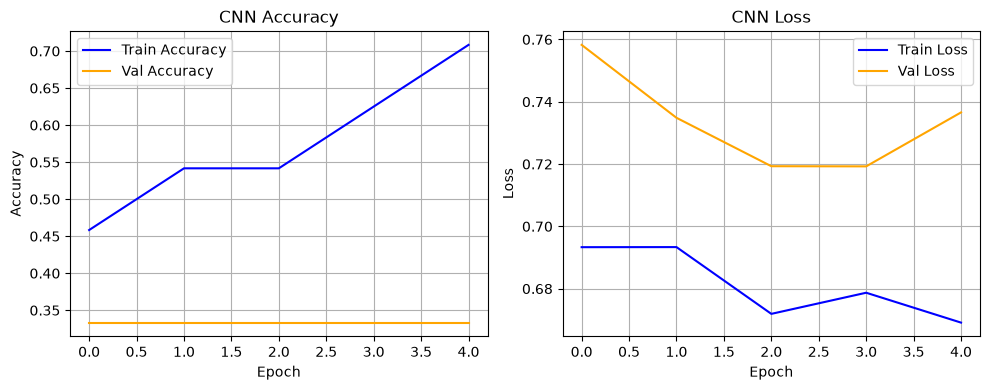


[✓] Model ready! Call predict_image('path_to_image.jpg') to test any image.


In [12]:
# ==============================================================================
# CNN Image Detection & Classification (Laptop-Optimized)
# From Prj01ImageDetection: Cat vs Dog / Binary Image Classifier
# ==============================================================================
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)

# ------------------------------------------------------------------------------
# 1. Configuration (Tuned for Laptop CPU: fast training, low RAM usage)
# ------------------------------------------------------------------------------
IMAGE_SIZE = (64, 64)   # 64x64 trains 4x faster on laptop CPU than 128x128
BATCH_SIZE = 32         # Smooth memory footprint
EPOCHS = 5              # Quick training cycles
dataset_dir = r"PetImages"  # Folder containing subfolders (e.g. PetImages/Cat, PetImages/Dog)

# If PetImages folder is not found, automatically create demo images for testing
if not os.path.exists(dataset_dir):
    print(f"\n[!] '{dataset_dir}' folder not found. Creating demo sample images so code runs right away...")
    for cat in ['Cat', 'Dog']:
        os.makedirs(os.path.join(dataset_dir, cat), exist_ok=True)
        for i in range(15):
            arr = np.random.randint(0, 256, (64, 64, 3), dtype=np.uint8)
            Image.fromarray(arr).save(os.path.join(dataset_dir, cat, f"sample_{i}.jpg"))
    print(f"[✓] Created demo dataset in '{dataset_dir}' with Cat and Dog classes.\n")

# ------------------------------------------------------------------------------
# 2. Dataset Sanitization: verify images & convert non-RGB safely
# ------------------------------------------------------------------------------
clean_count = 0
for root, _, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            fpath = os.path.join(root, file)
            try:
                img = Image.open(fpath)
                img.verify()
                img.close()
                img = Image.open(fpath)
                if img.mode != 'RGB':
                    img.convert('RGB').save(fpath)
                    clean_count += 1
                img.close()
            except Exception:
                try:
                    os.remove(fpath)
                except Exception:
                    pass
print(f"Sanitization Complete: Verified and cleaned {clean_count} images.")

# ------------------------------------------------------------------------------
# 3. Load Datasets with Keras image_dataset_from_directory
# ------------------------------------------------------------------------------
train_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes detected:", class_names)

# Performance optimization: cache and prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ------------------------------------------------------------------------------
# 4. Build Compact Convolutional Neural Network (CNN)
# ------------------------------------------------------------------------------
model = keras.Sequential([
    keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    layers.Rescaling(1.0 / 255),
    
    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Classification Head
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

# ------------------------------------------------------------------------------
# 5. Train Model (Fast laptop subset if dataset is very large)
# ------------------------------------------------------------------------------
num_batches = len(train_ds)
train_subset = train_ds.take(50) if num_batches > 50 else train_ds
val_subset = val_ds.take(15) if len(val_ds) > 15 else val_ds

print(f"\nTraining on {len(train_subset)} batches for {EPOCHS} epochs...")
history = model.fit(train_subset, validation_data=val_subset, epochs=EPOCHS)

# ------------------------------------------------------------------------------
# 6. Plot Training Accuracy and Loss Curves
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 7. Function to Predict Any Image
# ------------------------------------------------------------------------------
def predict_image(img_path):
    if not os.path.exists(img_path):
        print(f"Image '{img_path}' not found.")
        return
    img = keras.utils.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    
    score = model.predict(img_array)[0][0]
    label = class_names[1] if score > 0.5 else class_names[0]
    conf = score if score > 0.5 else 1 - score
    print(f"Result: {label} ({conf*100:.2f}% confidence)")
    
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"{label} ({conf*100:.1f}%)")
    plt.axis('off')
    plt.show()

print("\n[✓] Model ready! Call predict_image('path_to_image.jpg') to test any image.")


In [3]:
# ==============================================================================
# Prj 03: Real-Time Object Detection & Counting using YOLOv8 (Laptop-Optimized)
# ==============================================================================
import cv2
from ultralytics import YOLO, settings
# 1. Turn off telemetry tracking
settings.update({"sync": False})
# 2. Load the lightweight YOLOv8 Nano model (~6MB, runs fast on CPU)
print("Loading YOLOv8 nano model (downloads ~6MB automatically on first run)...")
model = YOLO('yolov8n.pt')
# 3. Open Laptop Camera with DirectShow and fallback support
def open_laptop_camera():
    # Try built-in camera with DirectShow backend (instant connection on Windows)
    cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    if cap.isOpened():
        ret, _ = cap.read()
        if ret:
            print("[OK] Connected to Camera 0 (DirectShow)")
            return cap
        cap.release()
    # Fallback to default backend for camera 0
    cap = cv2.VideoCapture(0)
    if cap.isOpened():
        ret, _ = cap.read()
        if ret:
            print("[OK] Connected to Camera 0 (Default)")
            return cap
        cap.release()
    # Fallback to camera 1 (if laptop has an external or secondary webcam)
    cap = cv2.VideoCapture(1, cv2.CAP_DSHOW)
    if cap.isOpened():
        ret, _ = cap.read()
        if ret:
            print("[OK] Connected to Camera 1 (DirectShow)")
            return cap
        cap.release()
    return None
cap = open_laptop_camera()
if cap is None or not cap.isOpened():
    print("\n[!] Camera could not be opened. Checklist:")
    print(" 1. Check Windows Privacy: Settings -> Privacy & Security -> Camera -> Allow apps to access your camera.")
    print(" 2. Close any apps using the camera (Zoom, Teams, Discord, Google Meet, Windows Camera app).")
    print(" 3. If run previously, restart the Jupyter kernel (Kernel -> Restart) to release the locked camera.")
    print(" 4. Check if your laptop has a physical webcam privacy slider or Fn camera key.\n")
else:
    # Set standard 640x480 resolution for smooth real-time performance on laptop CPU
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    print("\n[OK] Camera feed active! Look for the popup window.")
    print(" -> Press 'q' on the video window to quit cleanly.\n")
    try:
        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                print("Failed to grab camera frame.")
                break
            # Run YOLOv8 object detection on the current frame
            results = model(frame, verbose=False)
            # Count total objects detected in this frame
            detected_count = len(results[0].boxes)
            # Draw bounding boxes and labels directly on the frame
            annotated_frame = results[0].plot()
            # Display total count overlay on screen
            cv2.putText(
                annotated_frame,
                f"Total Objects Counted: {detected_count}",
                (20, 45),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,
                (0, 255, 0),
                2,
                cv2.LINE_AA,
            )
            # Show the live frame in an OpenCV window
            cv2.imshow("Day 4 - Live Object Counter (Press 'q' to quit)", annotated_frame)
            # Press 'q' to cleanly exit
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("Terminating live object counter...")
                break
    finally:
        # Always release the camera hardware cleanly to prevent locking
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)
        print("Camera feed released and windows closed successfully.")


Loading YOLOv8 nano model (downloads ~6MB automatically on first run)...
[OK] Connected to Camera 0 (DirectShow)

[OK] Camera feed active! Look for the popup window.
 -> Press 'q' on the video window to quit cleanly.

Terminating live object counter...
Camera feed released and windows closed successfully.


--- Paragraph Text ---
Artificial intelligence and machine learning are revolutionizing the modern world of computer science and technology.
Python has emerged as the most popular programming language for building deep neural networks and data science applications.
Data scientists analyze massive datasets using statistical algorithms, predictive modeling, and data visualization tools.
Computer vision allows intelligent systems to detect objects, recognize faces, and process real-time video streams.
Natural language processing empowers computers to comprehend human speech, tokenize text, and extract meaningful insights.
As technology advances, intelligent automation, cloud computing, and robotic systems continue to reshape innovation across industries.
Machine learning models learn complex patterns from data to improve classification accuracy and automated decision-making.
Artificial intelligence intelligence intelligence data data data machine learning learning learning Python Python t

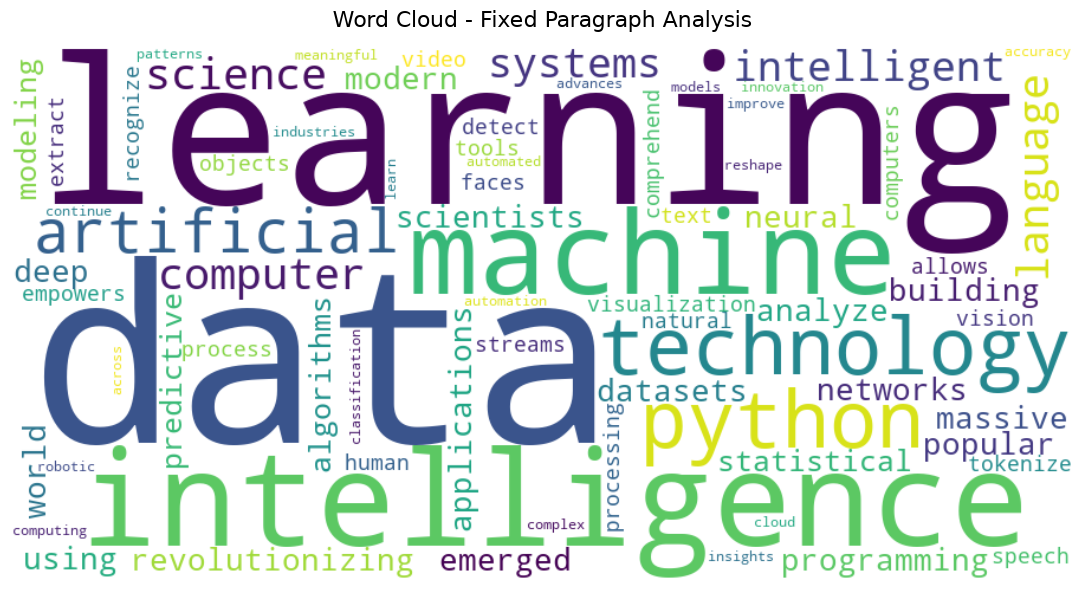

In [4]:
# ==============================================================================
# Word Cloud Generation from a Fixed Paragraph (NLTK & WordCloud)
# ==============================================================================
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# 1. Download required NLTK tokenizers and stopwords datasets
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# 2. Fixed Paragraph Text
text = """
Artificial intelligence and machine learning are revolutionizing the modern world of computer science and technology.
Python has emerged as the most popular programming language for building deep neural networks and data science applications.
Data scientists analyze massive datasets using statistical algorithms, predictive modeling, and data visualization tools.
Computer vision allows intelligent systems to detect objects, recognize faces, and process real-time video streams.
Natural language processing empowers computers to comprehend human speech, tokenize text, and extract meaningful insights.
As technology advances, intelligent automation, cloud computing, and robotic systems continue to reshape innovation across industries.
Machine learning models learn complex patterns from data to improve classification accuracy and automated decision-making.
Artificial intelligence intelligence intelligence data data data machine learning learning learning Python Python technology.
"""
print("--- Paragraph Text ---")
print(text.strip())
print("-----------------------\n")

# 3. Word Tokenization (convert to lowercase for uniformity)
words = word_tokenize(text.lower())
print("Total Words Tokenized:", len(words))

# 4. Filter out punctuation and stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word.isalpha() and word not in stop_words]
print("Filtered Meaningful Words:", len(filtered_words))

# 5. Calculate frequency distribution of words
word_freq = Counter(filtered_words)
print("\nTop 10 Most Frequent Words:")
for word, count in word_freq.most_common(10):
    print(f"  {word}: {count}")

# 6. Generate the Word Cloud
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate_from_frequencies(word_freq)

# 7. Plot and display the Word Cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axis ticks and numbers
plt.title('Word Cloud - Fixed Paragraph Analysis', fontsize=16, pad=15)
plt.tight_layout()
plt.show()
